In [1]:
# 💰 Price Per Sq.Ft Analysis

This notebook analyzes property prices on a per-square-foot basis.

Objectives:

- Calculate actual price per sq.ft
- Analyze predicted price per sq.ft
- Compare actual vs predicted price per sq.ft
- Compare properties with locality averages
- Identify relatively expensive and affordable properties
- Analyze price per sq.ft by locality
- Analyze price per sq.ft by property type
- Create visualizations
- Build a reusable price-per-sq.ft analysis function
- Save analysis results for Flask dashboard integration

SyntaxError: invalid syntax (2701865973.py, line 3)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
PROJECT_DIR = r"C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction"

PROCESSED_DIR = os.path.join(PROJECT_DIR, "processed")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nProcessed directory:")
print(PROCESSED_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)

Project directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction

Processed directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\processed

Output directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs


In [4]:
print("Searching for property_intelligence.csv...")
print()

found_files = []

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.lower() == "property_intelligence.csv":
            found_files.append(os.path.join(root, file))

if len(found_files) == 0:
    print("❌ property_intelligence.csv was NOT found.")
    print()
    print("Project folder checked:")
    print(PROJECT_DIR)

else:
    print("✅ File found!")
    print()

    for i, file_path in enumerate(found_files):
        print(f"{i + 1}. {file_path}")

    property_path = found_files[0]

    print()
    print("Selected file:")
    print(property_path)

Searching for property_intelligence.csv...

✅ File found!

1. C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed\property_intelligence.csv

Selected file:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed\property_intelligence.csv


In [5]:
df = pd.read_csv(property_path)

print("Dataset loaded successfully!")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!

Shape:
(51767, 22)

Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'predicted_price', 'price_difference', 'price_difference_percent', 'predicted_price_per_sqft', 'price_per_sqft_difference', 'anomaly_label', 'anomaly_score', 'is_anomaly']


In [6]:
display(df.head())

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.244410,73.123253,5.749573e+06,8.507096e+05,14.796047,7595.209299,1123.790701,1,0.261409,False
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.257294,73.148872,6.422073e+06,-2.522321e+05,-3.927581,9849.805444,-386.859125,1,0.257219,False
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,...,19.209026,73.081276,4.378319e+06,2.216174e+05,5.061702,11056.360025,559.639975,1,0.242774,False
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,...,19.097841,72.851158,5.084753e+07,1.132471e+06,2.227190,44997.813310,1002.186690,1,0.214435,False
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,...,19.420601,72.809319,3.663747e+06,2.512535e+05,6.857829,8422.405793,577.594207,1,0.208075,False


In [7]:
print("Dataset Information")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
display(df.dtypes)

Dataset Information
Rows: 51767
Columns: 22

Data Types:


price                          int64
area                           int64
price_per_sqft               float64
locality                         str
city                             str
property_type                    str
bedroom_num                    int64
bathroom_num                   int64
balcony_num                    int64
furnished                        str
age                            int64
total_floors                   int64
latitude                     float64
longitude                    float64
predicted_price              float64
price_difference             float64
price_difference_percent     float64
predicted_price_per_sqft     float64
price_per_sqft_difference    float64
anomaly_label                  int64
anomaly_score                float64
is_anomaly                      bool
dtype: object

In [8]:
required_columns = [
    "price",
    "area",
    "price_per_sqft",
    "locality",
    "city",
    "property_type",
    "predicted_price",
    "predicted_price_per_sqft"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:
    print("✅ All required columns are available.")

else:
    print("❌ Missing columns:")
    print(missing_columns)

✅ All required columns are available.


In [9]:
missing_values = df[required_columns].isnull().sum()

print("Missing Values")
print("=" * 60)

display(missing_values)

Missing Values


price                       0
area                        0
price_per_sqft              0
locality                    0
city                        0
property_type               0
predicted_price             0
predicted_price_per_sqft    0
dtype: int64

In [10]:
print("Actual Price Per Sq.Ft Statistics")
print("=" * 60)

display(
    df["price_per_sqft"].describe()
)

Actual Price Per Sq.Ft Statistics


count     51767.000000
mean      18390.293804
std       13099.807453
min          25.376685
25%        8901.538576
50%       15642.000000
75%       23855.656316
max      290000.000000
Name: price_per_sqft, dtype: float64

In [11]:
print("Predicted Price Per Sq.Ft Statistics")
print("=" * 60)

display(
    df["predicted_price_per_sqft"].describe()
)

Predicted Price Per Sq.Ft Statistics


count     51767.000000
mean      18445.114730
std       12414.412676
min        1597.091525
25%        9100.917946
50%       16193.157223
75%       23993.166407
max      191391.141449
Name: predicted_price_per_sqft, dtype: float64

In [12]:
comparison = df[
    [
        "price_per_sqft",
        "predicted_price_per_sqft"
    ]
].copy()

comparison["difference"] = (
    comparison["predicted_price_per_sqft"]
    - comparison["price_per_sqft"]
)

comparison["difference_percent"] = (
    comparison["difference"]
    / comparison["price_per_sqft"]
) * 100

display(comparison.head())

,price_per_sqft,predicted_price_per_sqft,difference,difference_percent
0,8719.000000,7595.209299,-1123.790701,-12.888986
1,9462.946319,9849.805444,386.859125,4.088147
2,11616.000000,11056.360025,-559.639975,-4.817837
3,46000.000000,44997.813310,-1002.186690,-2.178667
4,9000.000000,8422.405793,-577.594207,-6.417713


In [13]:
avg_actual_ppsf = df["price_per_sqft"].mean()
avg_predicted_ppsf = df["predicted_price_per_sqft"].mean()

print("Average Actual Price/Sq.Ft:")
print(f"₹{avg_actual_ppsf:,.2f}")

print("\nAverage Predicted Price/Sq.Ft:")
print(f"₹{avg_predicted_ppsf:,.2f}")

print("\nDifference:")
print(f"₹{avg_predicted_ppsf - avg_actual_ppsf:,.2f}")

Average Actual Price/Sq.Ft:
₹18,390.29

Average Predicted Price/Sq.Ft:
₹18,445.11

Difference:
₹54.82


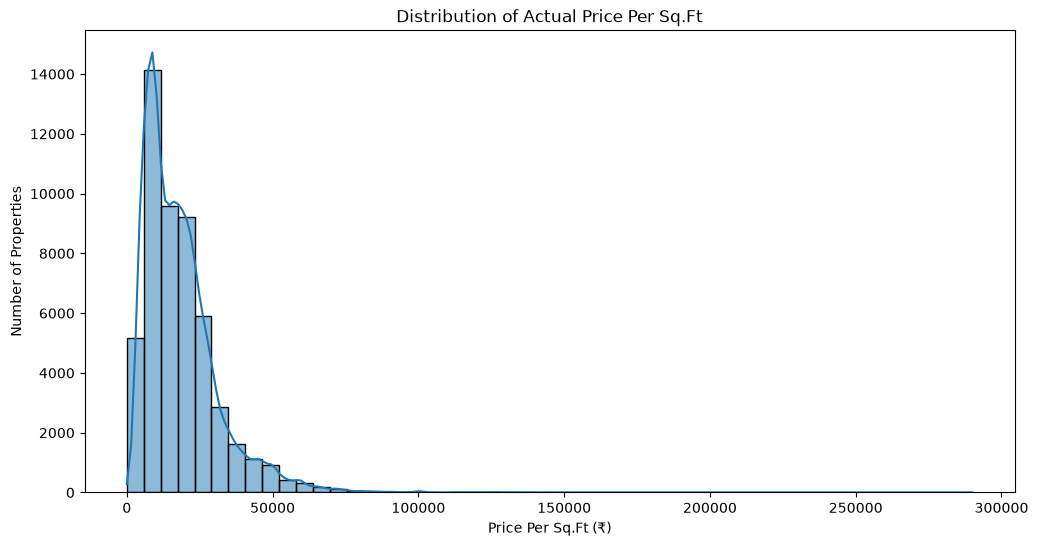

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["price_per_sqft"],
    bins=50,
    kde=True
)

plt.title("Distribution of Actual Price Per Sq.Ft")
plt.xlabel("Price Per Sq.Ft (₹)")
plt.ylabel("Number of Properties")

plt.show()

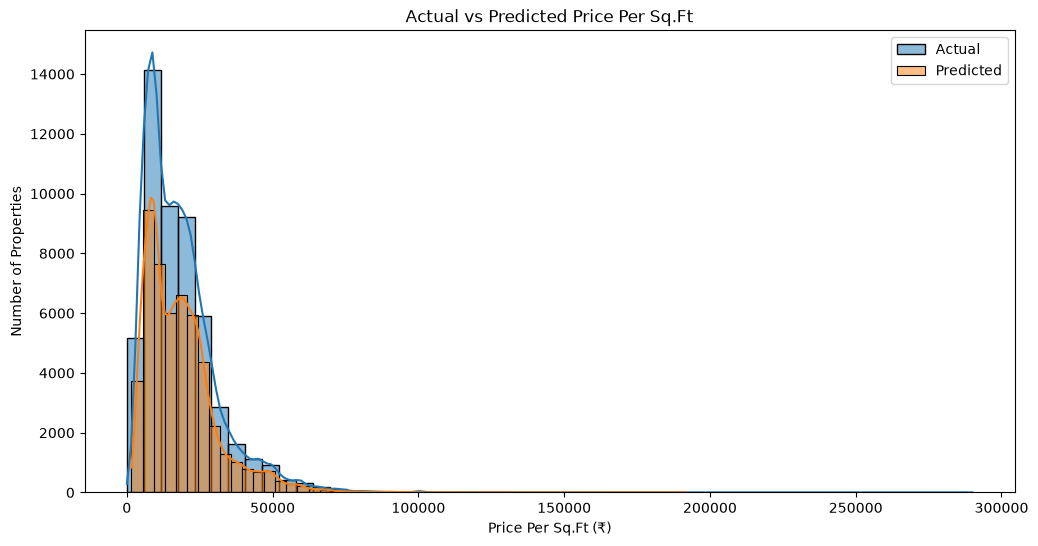

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["price_per_sqft"],
    bins=50,
    kde=True,
    label="Actual",
    alpha=0.5
)

sns.histplot(
    df["predicted_price_per_sqft"],
    bins=50,
    kde=True,
    label="Predicted",
    alpha=0.5
)

plt.title("Actual vs Predicted Price Per Sq.Ft")
plt.xlabel("Price Per Sq.Ft (₹)")
plt.ylabel("Number of Properties")

plt.legend()

plt.show()

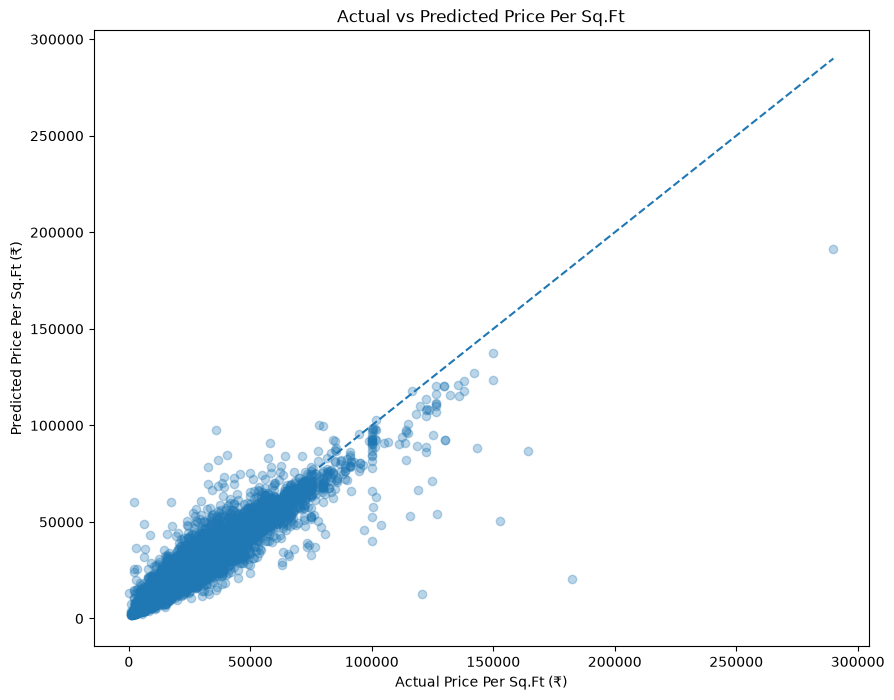

In [17]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["price_per_sqft"],
    df["predicted_price_per_sqft"],
    alpha=0.3
)

max_value = max(
    df["price_per_sqft"].max(),
    df["predicted_price_per_sqft"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Price Per Sq.Ft")

plt.xlabel("Actual Price Per Sq.Ft (₹)")
plt.ylabel("Predicted Price Per Sq.Ft (₹)")

plt.show()

In [18]:
df["ppsf_difference"] = (
    df["predicted_price_per_sqft"]
    - df["price_per_sqft"]
)

df["ppsf_difference_percent"] = (
    df["ppsf_difference"]
    / df["price_per_sqft"]
) * 100

display(
    df[
        [
            "price_per_sqft",
            "predicted_price_per_sqft",
            "ppsf_difference",
            "ppsf_difference_percent"
        ]
    ].head()
)

,price_per_sqft,predicted_price_per_sqft,ppsf_difference,ppsf_difference_percent
0,8719.000000,7595.209299,-1123.790701,-12.888986
1,9462.946319,9849.805444,386.859125,4.088147
2,11616.000000,11056.360025,-559.639975,-4.817837
3,46000.000000,44997.813310,-1002.186690,-2.178667
4,9000.000000,8422.405793,-577.594207,-6.417713


In [19]:
def classify_price_position(percent_difference):
    
    if percent_difference <= -15:
        return "Significantly Below Market"
    
    elif percent_difference <= -5:
        return "Below Market"
    
    elif percent_difference < 5:
        return "Near Market Value"
    
    elif percent_difference < 15:
        return "Above Market"
    
    else:
        return "Significantly Above Market"


df["price_position"] = df["ppsf_difference_percent"].apply(
    classify_price_position
)

display(
    df["price_position"].value_counts()
)

price_position
Near Market Value             25604
Above Market                   9793
Below Market                   8852
Significantly Above Market     5420
Significantly Below Market     2098
Name: count, dtype: int64

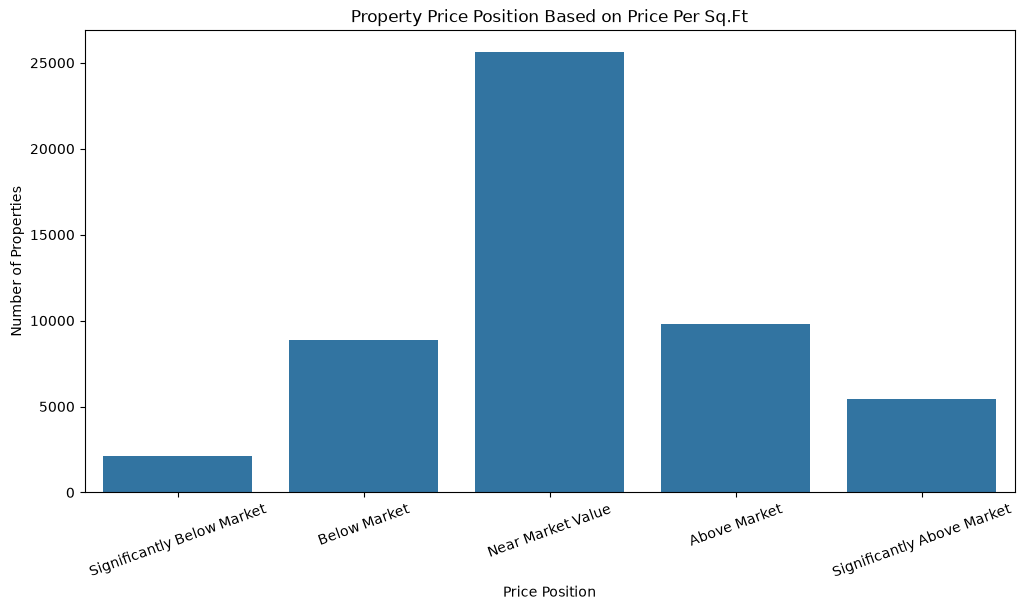

In [20]:
plt.figure(figsize=(12, 6))

order = [
    "Significantly Below Market",
    "Below Market",
    "Near Market Value",
    "Above Market",
    "Significantly Above Market"
]

sns.countplot(
    data=df,
    x="price_position",
    order=order
)

plt.title("Property Price Position Based on Price Per Sq.Ft")

plt.xlabel("Price Position")
plt.ylabel("Number of Properties")

plt.xticks(rotation=20)

plt.show()

In [21]:
locality_ppsf = (
    df.groupby("locality")
    .agg(
        property_count=("price_per_sqft", "count"),
        average_price_per_sqft=("price_per_sqft", "mean"),
        median_price_per_sqft=("price_per_sqft", "median"),
        average_predicted_price_per_sqft=(
            "predicted_price_per_sqft",
            "mean"
        )
    )
    .reset_index()
)

locality_ppsf = locality_ppsf.sort_values(
    "property_count",
    ascending=False
)

display(locality_ppsf.head(20))

,locality,property_count,average_price_per_sqft,median_price_per_sqft,average_predicted_price_per_sqft
363,Thane,5292,15598.323459,15136.843766,15622.130052
209,Mira Road,3162,11339.034222,10125.108677,11384.471559
142,Kandivali,2039,21087.237542,20289.855072,21077.387721
15,Andheri,2039,27220.837746,26371.308017,27539.108571
160,Kharghar,1904,11417.045883,10418.859649,11435.264937
85,Dombivali,1872,8231.365309,7846.153846,8265.417117
138,Kalyan,1738,7660.306629,7272.727273,7677.555581
46,Borivali,1678,23526.606611,22869.617312,23596.810176
58,Chembur,1591,23907.272463,23144.104803,23961.094285
193,Malad,1522,20924.351756,20795.010395,21076.004705


In [22]:
top_expensive_localities = (
    locality_ppsf
    .sort_values(
        "average_price_per_sqft",
        ascending=False
    )
    .head(15)
)

display(top_expensive_localities)

,locality,property_count,average_price_per_sqft,median_price_per_sqft,average_predicted_price_per_sqft
228,Napean Sea Road,1,132375.189673,132375.189673,115892.847271
201,Marine Drive,2,114175.602818,114175.602818,85488.554220
65,Churchgate,5,98918.281466,101839.754274,95290.818231
30,Bandstand,1,96296.296296,96296.296296,79511.111111
256,Pali Hill,3,90804.799648,115004.761240,79040.813396
7,Altamount Road,1,77777.777778,77777.777778,86739.681300
48,Breach Candy,2,77619.047619,77619.047619,66855.267062
192,Malabar Hill,36,76152.100253,62361.111111,75369.578876
1,Adarsh Nagar,2,72716.346154,72716.346154,67756.829785
93,Gamdevi,3,69457.117715,63291.139241,64473.684270


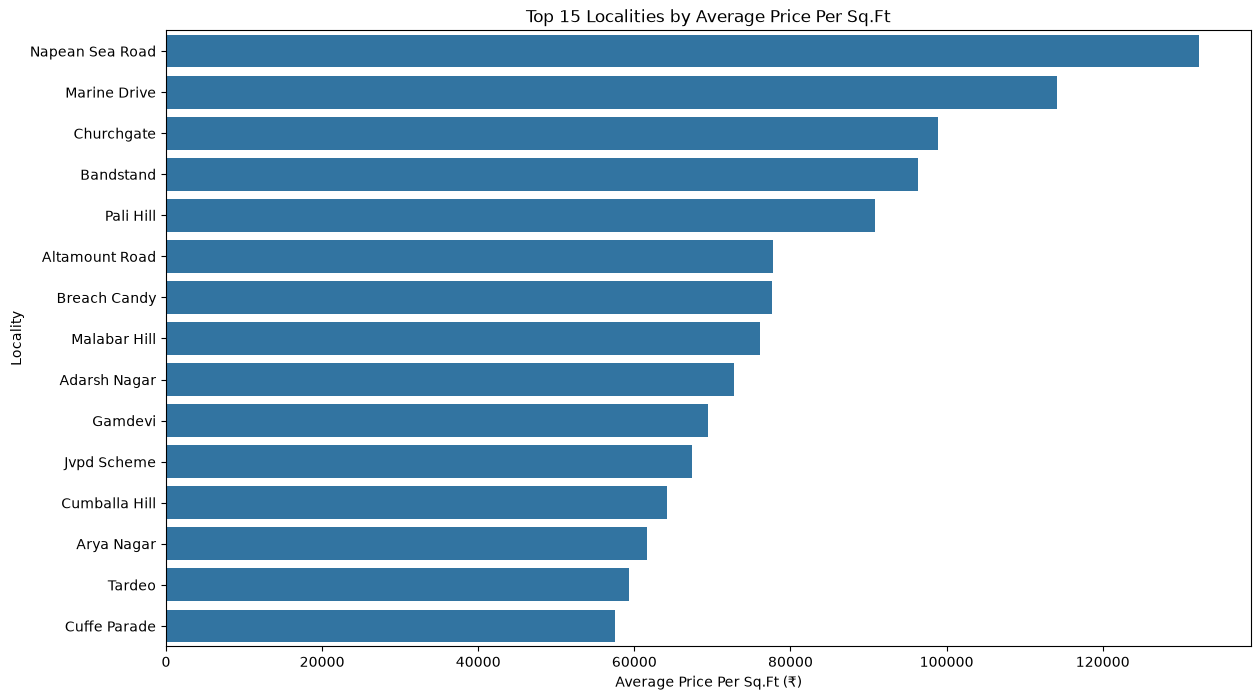

In [23]:
plt.figure(figsize=(14, 8))

plot_data = (
    locality_ppsf
    .sort_values(
        "average_price_per_sqft",
        ascending=False
    )
    .head(15)
)

sns.barplot(
    data=plot_data,
    x="average_price_per_sqft",
    y="locality"
)

plt.title("Top 15 Localities by Average Price Per Sq.Ft")

plt.xlabel("Average Price Per Sq.Ft (₹)")
plt.ylabel("Locality")

plt.show()

In [24]:
locality_comparison = (
    df.groupby("locality")
    .agg(
        actual_ppsf=("price_per_sqft", "mean"),
        predicted_ppsf=("predicted_price_per_sqft", "mean"),
        property_count=("price_per_sqft", "count")
    )
    .reset_index()
)

locality_comparison["difference"] = (
    locality_comparison["predicted_ppsf"]
    - locality_comparison["actual_ppsf"]
)

locality_comparison["difference_percent"] = (
    locality_comparison["difference"]
    / locality_comparison["actual_ppsf"]
) * 100

display(
    locality_comparison
    .sort_values("property_count", ascending=False)
    .head(20)
)

,locality,actual_ppsf,predicted_ppsf,property_count,difference,difference_percent
363,Thane,15598.323459,15622.130052,5292,23.806593,0.152623
209,Mira Road,11339.034222,11384.471559,3162,45.437337,0.400716
142,Kandivali,21087.237542,21077.387721,2039,-9.849822,-0.046710
15,Andheri,27220.837746,27539.108571,2039,318.270825,1.169218
160,Kharghar,11417.045883,11435.264937,1904,18.219054,0.159578
85,Dombivali,8231.365309,8265.417117,1872,34.051808,0.413684
138,Kalyan,7660.306629,7677.555581,1738,17.248953,0.225173
46,Borivali,23526.606611,23596.810176,1678,70.203565,0.298401
58,Chembur,23907.272463,23961.094285,1591,53.821822,0.225127
193,Malad,20924.351756,21076.004705,1522,151.652949,0.724768


In [25]:
property_type_ppsf = (
    df.groupby("property_type")
    .agg(
        property_count=("price_per_sqft", "count"),
        average_price_per_sqft=("price_per_sqft", "mean"),
        median_price_per_sqft=("price_per_sqft", "median"),
        predicted_price_per_sqft=(
            "predicted_price_per_sqft",
            "mean"
        )
    )
    .reset_index()
)

display(
    property_type_ppsf.sort_values(
        "average_price_per_sqft",
        ascending=False
    )
)

,property_type,property_count,average_price_per_sqft,median_price_per_sqft,predicted_price_per_sqft
3,Studio Apartment,2,28198.298308,28198.298308,29004.983370
1,Independent Floor,135,22903.928595,11111.111111,23421.602665
0,Apartment,50960,18459.142701,15816.326531,18512.612329
4,Villa,323,13031.590011,5714.285714,12724.187352
2,Independent House,347,11454.745751,7222.222222,11860.781314


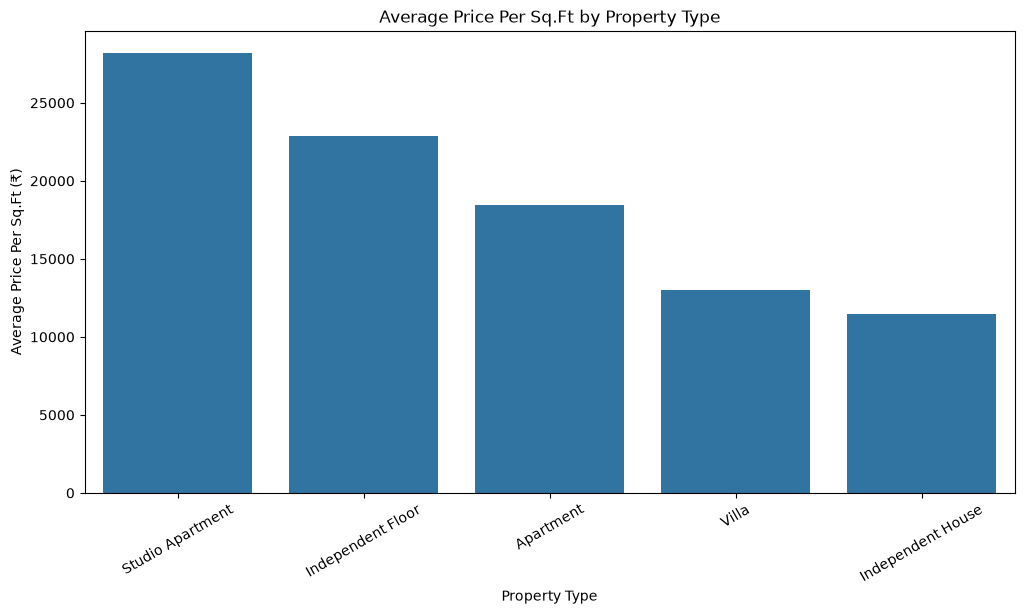

In [26]:
plt.figure(figsize=(12, 6))

plot_data = property_type_ppsf.sort_values(
    "average_price_per_sqft",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="property_type",
    y="average_price_per_sqft"
)

plt.title("Average Price Per Sq.Ft by Property Type")

plt.xlabel("Property Type")
plt.ylabel("Average Price Per Sq.Ft (₹)")

plt.xticks(rotation=30)

plt.show()

In [27]:
affordable_properties = df[
    df["ppsf_difference_percent"] <= -15
].copy()

print(
    "Properties Significantly Below Predicted Market Level:"
)
print(len(affordable_properties))

display(
    affordable_properties[
        [
            "price",
            "area",
            "locality",
            "property_type",
            "price_per_sqft",
            "predicted_price_per_sqft",
            "ppsf_difference_percent",
            "price_position"
        ]
    ]
    .sort_values(
        "ppsf_difference_percent"
    )
    .head(20)
)

Properties Significantly Below Predicted Market Level:
2098


,price,area,locality,property_type,price_per_sqft,predicted_price_per_sqft,ppsf_difference_percent,price_position
21149,145000000,1200,Thane,Apartment,120833.333333,12548.484875,-89.615047,Significantly Below Market
30440,142240000,780,Goregaon,Apartment,182358.974359,20383.787259,-88.822164,Significantly Below Market
5070,415800000,2725,Bandra,Apartment,152587.155963,50544.843955,-66.874772,Significantly Below Market
21403,35000000,1160,Thane,Apartment,30172.413793,11527.945402,-61.793095,Significantly Below Market
4826,11500000,350,Koper Khairane,Apartment,32857.142857,12765.302674,-61.149079,Significantly Below Market
14492,250000000,2500,Mahalaxmi,Apartment,100000.000000,40052.630637,-59.947369,Significantly Below Market
35342,8998000,349,Versova,Apartment,25782.234957,10414.199482,-59.607072,Significantly Below Market
42526,9500000,640,Kalyan,Apartment,14843.750000,6051.156887,-59.234311,Significantly Below Market
47585,360000000,10000,Nerul,Apartment,36000.000000,14996.841597,-58.342107,Significantly Below Market
12662,380000000,3000,Juhu,Villa,126666.666667,54188.282684,-57.219777,Significantly Below Market


In [28]:
expensive_properties = df[
    df["ppsf_difference_percent"] >= 15
].copy()

print(
    "Properties Significantly Above Predicted Market Level:"
)

print(len(expensive_properties))

display(
    expensive_properties[
        [
            "price",
            "area",
            "locality",
            "property_type",
            "price_per_sqft",
            "predicted_price_per_sqft",
            "ppsf_difference_percent",
            "price_position"
        ]
    ]
    .sort_values(
        "ppsf_difference_percent",
        ascending=False
    )
    .head(20)
)

Properties Significantly Above Predicted Market Level:
5420


,price,area,locality,property_type,price_per_sqft,predicted_price_per_sqft,ppsf_difference_percent,price_position
51222,32000,1261,Deonar,Apartment,25.376685,13185.958398,51860.917313,Significantly Above Market
49867,16005000,7000,Boisar,Independent House,2286.428571,60574.075116,2549.287884,Significantly Above Market
30061,1000000,500,Mumbai,Apartment,2000.000000,25532.080166,1176.604008,Significantly Above Market
28874,10498460,3658,Kanjurmarg,Apartment,2870.000000,36632.480765,1176.393058,Significantly Above Market
50556,4500000,2200,Thane,Apartment,2045.454545,23921.433006,1069.492280,Significantly Above Market
51678,12500000,2017,Chembur,Apartment,6197.322757,49143.907119,692.986085,Significantly Above Market
36517,10000000,2960,Uttan,Villa,3378.378378,25473.715088,654.021967,Significantly Above Market
41650,990000,515,Andheri,Apartment,1922.330097,14356.532351,646.829713,Significantly Above Market
6985,800000,800,Nalasopara,Apartment,1000.000000,7397.566560,639.756656,Significantly Above Market
4925,2700000,1260,Thane,Apartment,2142.857143,14663.811905,584.311222,Significantly Above Market


In [29]:
def get_locality_ppsf_benchmark(locality):
    
    locality_data = df[
        df["locality"].astype(str).str.lower()
        == str(locality).lower()
    ]
    
    if len(locality_data) == 0:
        return None
    
    return {
        "locality": locality,
        "property_count": len(locality_data),
        "average_price_per_sqft": float(
            locality_data["price_per_sqft"].mean()
        ),
        "median_price_per_sqft": float(
            locality_data["price_per_sqft"].median()
        ),
        "average_predicted_price_per_sqft": float(
            locality_data[
                "predicted_price_per_sqft"
            ].mean()
        )
    }


print("Function created successfully!")

Function created successfully!


In [30]:
sample_locality = df["locality"].dropna().iloc[0]

benchmark = get_locality_ppsf_benchmark(
    sample_locality
)

print("Sample Locality:")
print(sample_locality)

print("\nBenchmark:")
print(benchmark)

Sample Locality:
Kalyan

Benchmark:
{'locality': 'Kalyan', 'property_count': 1738, 'average_price_per_sqft': 7660.30662863341, 'median_price_per_sqft': 7272.727272727273, 'average_predicted_price_per_sqft': 7677.5555811614295}


In [31]:
def analyze_price_per_sqft(
    area,
    predicted_price,
    locality
):
    
    if area <= 0:
        return {
            "error": "Area must be greater than zero."
        }
    
    if predicted_price <= 0:
        return {
            "error": "Predicted price must be greater than zero."
        }
    
    user_ppsf = predicted_price / area
    
    benchmark = get_locality_ppsf_benchmark(locality)
    
    if benchmark is None:
        return {
            "user_price_per_sqft": float(user_ppsf),
            "locality": locality,
            "message": "Locality benchmark not available."
        }
    
    locality_avg = benchmark[
        "average_price_per_sqft"
    ]
    
    difference = user_ppsf - locality_avg
    
    difference_percent = (
        difference / locality_avg
    ) * 100
    
    if difference_percent <= -15:
        position = "Significantly Below Market"
    
    elif difference_percent <= -5:
        position = "Below Market"
    
    elif difference_percent < 5:
        position = "Near Market Value"
    
    elif difference_percent < 15:
        position = "Above Market"
    
    else:
        position = "Significantly Above Market"
    
    return {
        "locality": locality,
        "user_price_per_sqft": float(user_ppsf),
        "locality_average_price_per_sqft": float(
            locality_avg
        ),
        "difference": float(difference),
        "difference_percent": float(
            difference_percent
        ),
        "position": position,
        "property_count": benchmark[
            "property_count"
        ]
    }


print("Price-per-sq.ft analyzer created successfully!")

Price-per-sq.ft analyzer created successfully!


In [32]:
test_area = 850

test_predicted_price = 13500000

test_locality = df["locality"].dropna().iloc[0]

result = analyze_price_per_sqft(
    area=test_area,
    predicted_price=test_predicted_price,
    locality=test_locality
)

print("Price Per Sq.Ft Analysis")
print("=" * 60)

for key, value in result.items():
    print(f"{key}: {value}")

Price Per Sq.Ft Analysis
locality: Kalyan
user_price_per_sqft: 15882.35294117647
locality_average_price_per_sqft: 7660.30662863341
difference: 8222.046312543062
difference_percent: 107.33312269524471
position: Significantly Above Market
property_count: 1738


In [33]:
ppsf_summary = df[
    [
        "locality",
        "city",
        "property_type",
        "area",
        "price",
        "price_per_sqft",
        "predicted_price",
        "predicted_price_per_sqft",
        "ppsf_difference",
        "ppsf_difference_percent",
        "price_position"
    ]
].copy()

display(ppsf_summary.head())

,locality,city,property_type,area,price,price_per_sqft,predicted_price,predicted_price_per_sqft,ppsf_difference,ppsf_difference_percent,price_position
0,Kalyan,Mumbai,Apartment,757,6600283,8719.000000,5.749573e+06,7595.209299,-1123.790701,-12.888986,Below Market
1,Kalyan,Mumbai,Apartment,652,6169841,9462.946319,6.422073e+06,9849.805444,386.859125,4.088147,Near Market Value
2,Dombivali,Mumbai,Apartment,396,4599936,11616.000000,4.378319e+06,11056.360025,-559.639975,-4.817837,Near Market Value
3,Ville Parle,Mumbai,Apartment,1130,51980000,46000.000000,5.084753e+07,44997.813310,-1002.186690,-2.178667,Near Market Value
4,Nala Sopara,Mumbai,Apartment,435,3915000,9000.000000,3.663747e+06,8422.405793,-577.594207,-6.417713,Below Market


In [34]:
ppsf_output_path = os.path.join(
    OUTPUT_DIR,
    "price_per_sqft_analysis.csv"
)

ppsf_summary.to_csv(
    ppsf_output_path,
    index=False
)

print("✅ Price-per-sq.ft analysis saved!")

print(
    "Path:",
    ppsf_output_path
)

✅ Price-per-sq.ft analysis saved!
Path: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\price_per_sqft_analysis.csv


In [35]:
locality_output_path = os.path.join(
    OUTPUT_DIR,
    "locality_ppsf_benchmark.csv"
)

locality_ppsf.to_csv(
    locality_output_path,
    index=False
)

print("✅ Locality benchmark saved!")

print(
    "Path:",
    locality_output_path
)

✅ Locality benchmark saved!
Path: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\locality_ppsf_benchmark.csv


In [36]:
property_type_output_path = os.path.join(
    OUTPUT_DIR,
    "property_type_ppsf_analysis.csv"
)

property_type_ppsf.to_csv(
    property_type_output_path,
    index=False
)

print("✅ Property type analysis saved!")

print(
    "Path:",
    property_type_output_path
)

✅ Property type analysis saved!
Path: C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\property_type_ppsf_analysis.csv


In [37]:
print("Saved Files")
print("=" * 60)

saved_files = [
    ppsf_output_path,
    locality_output_path,
    property_type_output_path
]

for file_path in saved_files:
    
    if os.path.exists(file_path):
        print("✅", os.path.basename(file_path))
        
    else:
        print("❌", os.path.basename(file_path))
        

Saved Files
✅ price_per_sqft_analysis.csv
✅ locality_ppsf_benchmark.csv
✅ property_type_ppsf_analysis.csv


In [38]:
print("🏠 TOP POTENTIALLY AFFORDABLE PROPERTIES")
print("=" * 70)

top_affordable = (
    df[
        df["ppsf_difference_percent"] <= -15
    ]
    .sort_values(
        "ppsf_difference_percent"
    )
    [
        [
            "locality",
            "property_type",
            "area",
            "price",
            "price_per_sqft",
            "predicted_price_per_sqft",
            "ppsf_difference_percent"
        ]
    ]
    .head(10)
)

display(top_affordable)

🏠 TOP POTENTIALLY AFFORDABLE PROPERTIES


,locality,property_type,area,price,price_per_sqft,predicted_price_per_sqft,ppsf_difference_percent
21149,Thane,Apartment,1200,145000000,120833.333333,12548.484875,-89.615047
30440,Goregaon,Apartment,780,142240000,182358.974359,20383.787259,-88.822164
5070,Bandra,Apartment,2725,415800000,152587.155963,50544.843955,-66.874772
21403,Thane,Apartment,1160,35000000,30172.413793,11527.945402,-61.793095
4826,Koper Khairane,Apartment,350,11500000,32857.142857,12765.302674,-61.149079
14492,Mahalaxmi,Apartment,2500,250000000,100000.000000,40052.630637,-59.947369
35342,Versova,Apartment,349,8998000,25782.234957,10414.199482,-59.607072
42526,Kalyan,Apartment,640,9500000,14843.750000,6051.156887,-59.234311
47585,Nerul,Apartment,10000,360000000,36000.000000,14996.841597,-58.342107
12662,Juhu,Villa,3000,380000000,126666.666667,54188.282684,-57.219777


In [39]:
print("💎 TOP POTENTIALLY EXPENSIVE PROPERTIES")
print("=" * 70)

top_expensive = (
    df[
        df["ppsf_difference_percent"] >= 15
    ]
    .sort_values(
        "ppsf_difference_percent",
        ascending=False
    )
    [
        [
            "locality",
            "property_type",
            "area",
            "price",
            "price_per_sqft",
            "predicted_price_per_sqft",
            "ppsf_difference_percent"
        ]
    ]
    .head(10)
)

display(top_expensive)

💎 TOP POTENTIALLY EXPENSIVE PROPERTIES


,locality,property_type,area,price,price_per_sqft,predicted_price_per_sqft,ppsf_difference_percent
51222,Deonar,Apartment,1261,32000,25.376685,13185.958398,51860.917313
49867,Boisar,Independent House,7000,16005000,2286.428571,60574.075116,2549.287884
30061,Mumbai,Apartment,500,1000000,2000.000000,25532.080166,1176.604008
28874,Kanjurmarg,Apartment,3658,10498460,2870.000000,36632.480765,1176.393058
50556,Thane,Apartment,2200,4500000,2045.454545,23921.433006,1069.492280
51678,Chembur,Apartment,2017,12500000,6197.322757,49143.907119,692.986085
36517,Uttan,Villa,2960,10000000,3378.378378,25473.715088,654.021967
41650,Andheri,Apartment,515,990000,1922.330097,14356.532351,646.829713
6985,Nalasopara,Apartment,800,800000,1000.000000,7397.566560,639.756656
4925,Thane,Apartment,1260,2700000,2142.857143,14663.811905,584.311222


In [41]:
print("📊 PRICE PER SQ.FT ANALYSIS SUMMARY")
print("=" * 70)

total_properties = len(df)

average_actual = df["price_per_sqft"].mean()
median_actual = df["price_per_sqft"].median()
average_predicted = df["predicted_price_per_sqft"].mean()

below_market = (
    df["ppsf_difference_percent"] <= -5
).sum()

near_market = (
    (df["ppsf_difference_percent"] > -5)
    & (df["ppsf_difference_percent"] < 5)
).sum()

above_market = (
    df["ppsf_difference_percent"] >= 5
).sum()

print(f"Total Properties: {total_properties:,}")

print(
    f"Average Actual Price/Sq.Ft: "
    f"₹{average_actual:,.2f}"
)

print(
    f"Median Actual Price/Sq.Ft: "
    f"₹{median_actual:,.2f}"
)

print(
    f"Average Predicted Price/Sq.Ft: "
    f"₹{average_predicted:,.2f}"
)

print(
    f"Properties Below Market: "
    f"{below_market:,}"
)

print(
    f"Properties Near Market: "
    f"{near_market:,}"
)

print(
    f"Properties Above Market: "
    f"{above_market:,}"
)

📊 PRICE PER SQ.FT ANALYSIS SUMMARY
Total Properties: 51,767
Average Actual Price/Sq.Ft: ₹18,390.29
Median Actual Price/Sq.Ft: ₹15,642.00
Average Predicted Price/Sq.Ft: ₹18,445.11
Properties Below Market: 10,950
Properties Near Market: 25,604
Properties Above Market: 15,213


In [42]:
# ✅ Conclusion

The Price Per Sq.Ft Analysis has been completed successfully.

The analysis provides:

- Actual price per sq.ft
- Predicted price per sq.ft
- Actual vs predicted comparison
- Price difference percentage
- Property price-position classification
- Locality-wise price per sq.ft
- Property-type-wise price per sq.ft
- Potentially affordable properties
- Potentially expensive properties
- Locality price benchmarks
- Reusable price-per-sq.ft analyzer
- CSV files for Flask dashboard integration

Output files:

1. `price_per_sqft_analysis.csv`
2. `locality_ppsf_benchmark.csv`
3. `property_type_ppsf_analysis.csv`

These outputs can later be integrated into the Flask property valuation dashboard.

SyntaxError: invalid syntax (162787673.py, line 3)